# First Model

Attempt to train a simple net using all the features we have amassed. 

Hyperparameters
- batch size
- learning rate
- epochs 

Features
- include or not to include - the rolling averages (and if so for how many periods)
- SMOTE - should we keep it? and if yes whats the k value

Model architecture
- number of layers
- dimensions per layer
- dropout

Performance
- better metrics than accuracy

Goal: get loss below 1, since that's just a random classifier

Next steps: Improve metrics by doing the stuff above, save graphs for different model configurations, then follow the paper (ex: SHAP stuff)

In [1]:
seed = 42
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack
import torch
from torch import nn
from tqdm import tqdm
from torch.utils.data import TensorDataset, DataLoader
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Collect the data

In [3]:
# step 1: Read the csvs
beige_df = pd.read_csv("data/beige_book_1996_2025.csv")
labels_df = pd.read_csv("data/filtered_labels.csv")
lm_sentiment_df = pd.read_csv('data/beige_book_sentiment_scores_1996_2025.csv')
market_futures_df = pd.read_csv('data/futures_with_diff.csv')

# column to merge on is timestamp
labels_df['timestamp'] = labels_df['observation_date']
market_futures_df['timestamp'] = market_futures_df['exp_date']
beige_df = pd.merge(beige_df, labels_df, on='timestamp', how='inner')
beige_df = pd.merge(beige_df, lm_sentiment_df, on='timestamp', how='inner')
beige_df = pd.merge(beige_df, market_futures_df, on='timestamp', how='inner')

# process the columns
beige_df['text'] = beige_df['text_x']
beige_df['url'] = beige_df['url_x']
beige_df['month'] = beige_df['month_x']
beige_df['year'] = beige_df['year_x']
beige_df = beige_df.drop(['year_x', 'month_x', 'url_x', 'text_x'], axis=1)
beige_df = beige_df.drop(['Unnamed: 0', 'Unnamed: 0_x', 'Unnamed: 0_y', 'observation_date', 'exp_date'], axis=1)
beige_df = beige_df.drop(['year_y', 'month_y', 'url_y', 'text_y'], axis=1)

# add average for new columns
beige_df['negative_score_10_mean'] = beige_df['negative_score'].rolling(window=10, min_periods=1).mean().shift(1)
beige_df['positive_score_10_mean'] = beige_df['positive_score'].rolling(window=10, min_periods=1).mean().shift(1)
beige_df['uncertainty_score_10_mean'] = beige_df['uncertainty_score'].rolling(window=10, min_periods=1).mean().shift(1)
beige_df['futures_price_10_mean'] = beige_df['futures_price'].rolling(window=10, min_periods=1).mean().shift(1)
beige_df['implied_rate_10_mean'] = beige_df['implied_rate'].rolling(window=10, min_periods=1).mean().shift(1)
beige_df['implied_rate_diff_10_mean'] = beige_df['implied_rate_diff'].rolling(window=10, min_periods=1).mean().shift(1)

beige_df = beige_df.drop(index=0) # first row is na

# sort by timestamp
final_df = beige_df.sort_values(by='timestamp')

print(len(final_df))
print(final_df.columns)
final_df.head()

231
Index(['timestamp', 'rate', 'decision', 'negative_score', 'positive_score',
       'uncertainty_score', '52W_high', '52W_low', '52W_pct_chg',
       'futures_price', 'implied_rate', 'implied_rate_diff', 'text', 'url',
       'month', 'year', 'negative_score_10_mean', 'positive_score_10_mean',
       'uncertainty_score_10_mean', 'futures_price_10_mean',
       'implied_rate_10_mean', 'implied_rate_diff_10_mean'],
      dtype='object')


,timestamp,rate,decision,negative_score,positive_score,uncertainty_score,52W_high,52W_low,52W_pct_chg,futures_price,...,text,url,month,year,negative_score_10_mean,positive_score_10_mean,uncertainty_score_10_mean,futures_price_10_mean,implied_rate_10_mean,implied_rate_diff_10_mean
1,1996-12-01,5.25,hold,0.014639,0.024703,0.007319,95.52,94.00,-0.62,94.660,...,moderate economic growth continues to be repor...,https://www.federalreserve.gov/fomc/beigebook/...,12,1996,0.029883,0.029883,0.010204,94.750000,5.250000,-0.04500
2,1997-01-01,5.25,hold,0.035156,0.026367,0.004883,95.52,93.90,-0.63,94.745,...,most district reports characterized early autu...,https://www.federalreserve.gov/fomc/beigebook/...,1,1997,0.022261,0.027293,0.008762,94.705000,5.295000,-0.01750
3,1997-03-01,5.25,hold,0.023581,0.020087,0.006114,94.73,93.68,0.57,94.635,...,district economies generally continue to expan...,https://www.federalreserve.gov/fomc/beigebook/...,3,1997,0.026559,0.026984,0.007469,94.718333,5.281667,-0.04000
4,1997-05-01,5.50,raise,0.027429,0.028997,0.001567,94.70,93.79,0.54,94.490,...,district economies generally continued to expa...,https://www.federalreserve.gov/fomc/beigebook/...,5,1997,0.025815,0.025260,0.007130,94.697500,5.302500,0.01625
5,1997-06-01,5.50,hold,0.031159,0.018116,0.005797,94.68,94.29,0.10,94.465,...,all twelve district economies expanded in may ...,https://www.federalreserve.gov/fomc/beigebook/...,6,1997,0.026138,0.026007,0.006017,94.656000,5.344000,0.01300


# Feature Engineering?

In [4]:
# step 2: standardize the labels (so numeric labels of 0, 1, 2)
label_encoder = LabelEncoder()
final_df['labels'] = label_encoder.fit_transform(final_df['decision'])

In [5]:
# step 3: Train-test split (60-20-20 split)
X = final_df[['timestamp', 'rate', 'negative_score', 'positive_score',
        'uncertainty_score', '52W_high', '52W_low', '52W_pct_chg',
        'futures_price', 'implied_rate', 'implied_rate_diff', 'text', 'url',
        'month', 'year', 'negative_score_10_mean', 'positive_score_10_mean',
        'uncertainty_score_10_mean', 'futures_price_10_mean',
        'implied_rate_10_mean', 'implied_rate_diff_10_mean']]
y = final_df['labels']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, random_state=seed, test_size=0.3, shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, random_state=seed, test_size=0.5, shuffle=False)

print(len(X_train), len(X_val), len(X_test))

161 35 35


In [6]:
# step 4: Generate TF-IDF encodings for the text
tf_idf_vectorizer = TfidfVectorizer()
X_text_train = tf_idf_vectorizer.fit_transform(X_train['text'])
X_text_val = tf_idf_vectorizer.transform(X_val['text'])
X_text_test = tf_idf_vectorizer.transform(X_test['text'])

print(X_text_train.shape, X_text_val.shape, X_text_test.shape)


(161, 9619) (35, 9619) (35, 9619)


In [7]:
scaler = StandardScaler()
# columns_to_scale = ['rate', 'negative_score', 'positive_score', 'uncertainty_score', '52W_high', '52W_low', '52W_pct_chg', 'futures_price', 'implied_rate', 'implied_rate_diff', 'negative_score_10_mean', 'positive_score_10_mean',
#         'uncertainty_score_10_mean', 'futures_price_10_mean', 'implied_rate_10_mean', 'implied_rate_diff_10_mean']
columns_to_scale = ['rate', 'negative_score', 'positive_score', 'uncertainty_score', '52W_high', '52W_low', '52W_pct_chg', 'futures_price', 'implied_rate', 'implied_rate_diff']

X_nums_train = scaler.fit_transform(X_train[columns_to_scale])
X_nums_val   = scaler.transform(X_val[columns_to_scale])
X_nums_test  = scaler.transform(X_test[columns_to_scale])

print(X_nums_train.shape, X_nums_val.shape, X_nums_test.shape)

(161, 10) (35, 10) (35, 10)


In [8]:
X_date_train = (pd.to_datetime(X_train['timestamp']) - pd.to_datetime((X_train['timestamp']).min())).dt.days.to_numpy().reshape(-1, 1)
X_date_val = (pd.to_datetime(X_val['timestamp']) - pd.to_datetime((X_train['timestamp']).min())).dt.days.to_numpy().reshape(-1, 1)
X_date_test = (pd.to_datetime(X_test['timestamp']) - pd.to_datetime((X_train['timestamp']).min())).dt.days.to_numpy().reshape(-1, 1)

print(X_date_train.shape, X_date_val.shape, X_date_test.shape)

(161, 1) (35, 1) (35, 1)


In [9]:
# using scipy sparse hstack since text is sparse
# X_train = hstack([X_nums_train, X_date_train, X_text_train])
# X_val = hstack([X_nums_val, X_date_val, X_text_val])
# X_test = hstack([X_nums_test, X_date_test, X_text_test])

X_train = hstack([X_nums_train, X_text_train])
X_val = hstack([X_nums_val, X_text_val])
X_test = hstack([X_nums_test, X_text_test])

print(X_train.shape, X_val.shape, X_test.shape)

(161, 9629) (35, 9629) (35, 9629)


In [10]:
# SMOTE stuff
smote = SMOTE(sampling_strategy='not majority', random_state=seed)
X_train, y_train = smote.fit_resample(X_train, y_train)

## Make the model

In [11]:
class FirstExperimentModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        # input layer, starting with 512 since i've not seen 1024 before, setting high dropout
        self.input_layer = nn.Sequential(nn.Linear(input_dim, 512), nn.ReLU(), nn.Dropout(0.3))

        # hidden layer, reducing dims further
        self.hidden_layer = nn.Sequential(nn.Linear(512, 64), nn.ReLU(), nn.Dropout(0.3))

        # output layer without softmax
        self.output_layer = nn.Linear(64, 3)

        # all together now
        self.net = nn.Sequential(self.input_layer, self.hidden_layer, self.output_layer)
    
    def forward(self, x):
        return self.net(x)
    
model = FirstExperimentModel(X_train.shape[1])
model.to(device)
print(model.net)

Sequential(
  (0): Sequential(
    (0): Linear(in_features=9629, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (1): Sequential(
    (0): Linear(in_features=512, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (2): Linear(in_features=64, out_features=3, bias=True)
)


In [12]:
# define cost-sensitive loss function
# inspiration: https://medium.com/nerd-for-tech/review-cb-loss-class-balanced-loss-based-on-effective-number-of-samples-image-classification-3056a1a1a001
weights = 1.0 / np.bincount(y_train.values)
weights = weights / weights.sum()
weights = torch.tensor(weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, device=device))

lr = 0.0001 # making this v small since we have less data
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

/var/folders/fh/d8z4d5wn6l51hqgtfycpk26r0000gn/T/ipykernel_47010/2746057137.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, device=device))


## Training Loop

TODO: figure out how to save the best model by tracking the best validation error seen per epoch

In [13]:
num_epochs = 25 # idk apparently for tf-idf you need large epochs
batch_size = 16 # this is sort of random (smaller might work better since we have less data to begin with)

In [14]:
# heavily copied from HW4

def train(data_loader, model, criterion, optimizer, device):
    train_avg_loss = 0
    num_correct = 0

    model.train()
    for feats, labels in tqdm(data_loader):
        optimizer.zero_grad()
        feats = feats.to(device)
        labels = labels.long().to(device)

        # Perform forward pass and calculate avg loss over all time steps
        logits = model(feats)
        loss = criterion(logits, labels)
        num_correct += torch.sum(torch.argmax(logits, dim=1) == labels)

        # Backward pass, update weights
        loss.backward()
        optimizer.step()

        train_avg_loss += loss.item()*feats.shape[0]

    # Uncomment the line below once the training loop is implemented to print 
    # the loss and accuracy at the end of each epoch
    print(f"Train loss: {train_avg_loss/len(data_loader.dataset)} | Accuracy: {num_correct/len(data_loader.dataset)}")
    return train_avg_loss/len(data_loader.dataset)

def val(data_loader, model, criterion, device):
    val_avg_loss = 0
    num_correct = 0

    model.eval()
    with torch.no_grad():
        for feats, labels in tqdm(data_loader):
            feats = feats.to(device)
            labels = labels.long().to(device)

            # Perform forward pass and calculate avg loss over all time steps
            logits = model(feats)
            loss = criterion(logits, labels)
            num_correct += torch.sum(torch.argmax(logits, dim=1) == labels)

            val_avg_loss += loss.item()*feats.shape[0]

    print(f"Val loss: {val_avg_loss/len(data_loader.dataset)} | Accuracy: {num_correct/len(data_loader.dataset)}")
    return val_avg_loss/len(data_loader.dataset)

In [15]:
X_train_dense = torch.tensor(X_train.toarray(), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
train_dataset = TensorDataset(X_train_dense, y_train_tensor)

X_val_dense = torch.tensor(X_val.toarray(), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
val_dataset = TensorDataset(X_val_dense, y_val_tensor)

# shuffling right now but I'm not sure if we should based on timestamps
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

train_loss_list, val_loss_list = [], []
for epoch in range(num_epochs):
    print(f"Epoch {epoch}")
    train_loss_list.append(train(train_dataloader, model, criterion, optimizer, device))
    val_loss_list.append(val(val_dataloader, model, criterion, device))

Epoch 0


100%|██████████| 22/22 [00:00<00:00, 91.43it/s]


Train loss: 1.0926724544469861 | Accuracy: 0.3333333432674408


100%|██████████| 3/3 [00:00<00:00, 563.15it/s]


Val loss: 1.0653448445456368 | Accuracy: 0.6857143044471741
Epoch 1


...

Val loss: 1.2406023072344916 | Accuracy: 0.800000011920929
Epoch 24


100%|██████████| 22/22 [00:00<00:00, 103.00it/s]


Train loss: 0.13385581788809403 | Accuracy: 0.9623188376426697


100%|██████████| 3/3 [00:00<00:00, 482.88it/s]

Val loss: 1.2747048373733247 | Accuracy: 0.7714285850524902


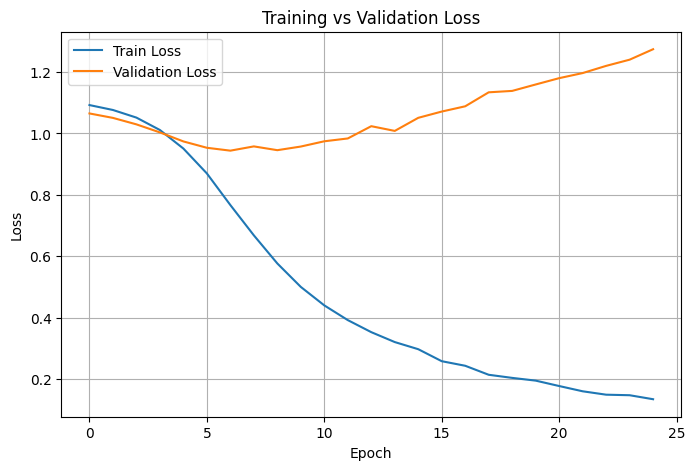

In [16]:
# with last year avg
plt.figure(figsize=(8,5))
plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# with last year avg
def actual_vs_pred(data_loader, model, device):
    all_preds = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for feats, labels in tqdm(data_loader):
            feats = feats.to(device)
            labels = labels.long().to(device)

            # Perform forward pass
            logits = model(feats)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return pd.DataFrame({"actual": all_labels, "predicted": all_preds})

actual_vs_pred(val_dataloader, model, device)

100%|██████████| 3/3 [00:00<00:00, 605.94it/s]


,actual,predicted
0,2,2
1,0,0
2,2,2
3,0,0
4,0,2
5,0,0
6,2,2
7,0,2
8,2,2
9,0,0


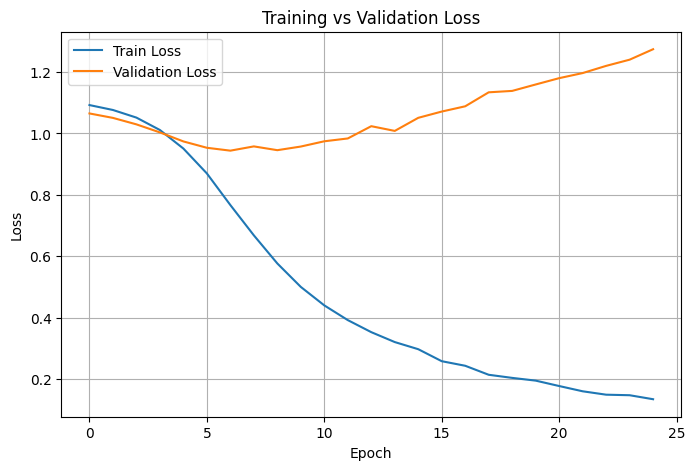

In [18]:
plt.figure(figsize=(8,5))
plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
def actual_vs_pred(data_loader, model, device):
    all_preds = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for feats, labels in tqdm(data_loader):
            feats = feats.to(device)
            labels = labels.long().to(device)

            # Perform forward pass
            logits = model(feats)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return pd.DataFrame({"actual": all_labels, "predicted": all_preds})

actual_vs_pred(val_dataloader, model, device)

100%|██████████| 3/3 [00:00<00:00, 585.03it/s]


,actual,predicted
0,2,2
1,0,0
2,2,2
3,0,0
4,0,2
5,0,0
6,2,2
7,0,2
8,2,2
9,0,0
